# Evaluating KANs vs MLPs for MNIST Classification in FL

This notebook is based mainly on the Flower Tutorial "Use a federated learning strategy", found in https://flower.ai/docs/framework/tutorial-series-use-a-federated-learning-strategy-pytorch.html .

## Global Values

In [ ]:
NUM_PARTITIONS = 100
BATCH_SIZE = 64
LOCAL_EPOCHS = 5
FRACTION_CLIENTS = 0.1
COMM_ROUNDS = 100
NET_TYPE = "fastkan"
LEARNING_RATE = 0.1
MOMENTUM = 0.9
HISTORY = {}
TRY_DEVICE = "cuda" # 'cuda' for gpu
SEED = 249

## Dependencies

In [ ]:
!pip install -q flwr[simulation] flwr-datasets[vision] torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.7/66.7 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.1/250.1 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 703.2/703.2 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.0/87.0 kB 8.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is th

In [ ]:
# Efficient KAN
!pip install -q git+https://github.com/Blealtan/efficient-kan.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install -q git+https://github.com/ZiyaoLi/fast-kan.git

  Preparing metadata (setup.py) ... done


In [ ]:
from collections import OrderedDict
from typing import Dict, List, Optional, Tuple

import random
import os
import re
import json
from logging import INFO

from google.colab import drive

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import flwr
from flwr.client import Client, ClientApp, NumPyClient
from flwr.server import ServerApp, ServerConfig, ServerAppComponents, SimpleClientManager
from flwr.server.strategy import FedAvg, FedAdagrad
from flwr.simulation import run_simulation, start_simulation
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import PathologicalPartitioner, NaturalIdPartitioner
from flwr_datasets.visualization import plot_label_distributions
from flwr.common import ndarrays_to_parameters, NDArrays, Scalar, Context, Metrics
from flwr.common.logger import log
from flwr.server.client_proxy import ClientProxy
from flwr.server.criterion import Criterion
from flwr_datasets.preprocessor import Divider

# from efficient_kan import KAN
# from fastkan import FastKAN

DEVICE = torch.device(TRY_DEVICE)  # "cpu" or "cuda" ("mps" for Apple Silicon)
print(f"Training on {DEVICE}")
print(f"Flower {flwr.__version__} / PyTorch {torch.__version__}")

Training on cuda
Flower 1.22.0 / PyTorch 2.8.0+cu126


##Pure KAN classes

In [ ]:
class PureKANLinear(torch.nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_spline=1.0,
        enable_standalone_scale_spline=True,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(PureKANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        # construct the grid
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (
                torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0]
            )
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

        # spline weights
        self.spline_weight = torch.nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        if enable_standalone_scale_spline:
            self.spline_scaler = torch.nn.Parameter(
                torch.Tensor(out_features, in_features)
            )

        self.scale_noise = scale_noise
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        with torch.no_grad():
            noise = (
                (
                    torch.rand(self.grid_size + 1, self.in_features, self.out_features)
                    - 0.5
                )
                * self.scale_noise
                / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(
                    self.grid.T[self.spline_order : -self.spline_order],
                    noise,
                )
            )
            if self.enable_standalone_scale_spline:
                torch.nn.init.constant_(self.spline_scaler, self.scale_spline)

    def b_splines(self, x: torch.Tensor):
        assert x.dim() == 2 and x.size(1) == self.in_features

        grid: torch.Tensor = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)])
                / (grid[:, k:-1] - grid[:, : -(k + 1)])
                * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x)
                / (grid[:, k + 1 :] - grid[:, 1:(-k)])
                * bases[:, :, 1:]
            )

        return bases.contiguous()

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        assert x.dim() == 2 and x.size(1) == self.in_features
        assert y.size() == (x.size(0), self.in_features, self.out_features)

        A = self.b_splines(x).transpose(0, 1)
        B = y.transpose(0, 1)
        solution = torch.linalg.lstsq(A, B).solution
        result = solution.permute(2, 0, 1)
        return result.contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * (
            self.spline_scaler.unsqueeze(-1)
            if self.enable_standalone_scale_spline
            else 1.0
        )

    def forward(self, x: torch.Tensor):
        assert x.size(-1) == self.in_features
        original_shape = x.shape
        x = x.reshape(-1, self.in_features)

        # PURE spline output (no base/linear part)
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )

        output = spline_output.reshape(*original_shape[:-1], self.out_features)
        return output


class PureKAN(torch.nn.Module):
    def __init__(
        self,
        layers_hidden,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_spline=1.0,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(PureKAN, self).__init__()

        self.layers = torch.nn.ModuleList()
        for in_features, out_features in zip(layers_hidden, layers_hidden[1:]):
            self.layers.append(
                PureKANLinear(
                    in_features,
                    out_features,
                    grid_size=grid_size,
                    spline_order=spline_order,
                    scale_noise=scale_noise,
                    scale_spline=scale_spline,
                    grid_eps=grid_eps,
                    grid_range=grid_range,
                )
            )

    def forward(self, x: torch.Tensor):
        for layer in self.layers:
            x = layer(x)
        return x


##RBF KAN Classes

In [ ]:
# Copyright 2024 Li, Ziyao
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.


import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from typing import *

class SplineLinear(nn.Linear):
    def __init__(self, in_features: int, out_features: int, init_scale: float = 0.1, **kw) -> None:
        self.init_scale = init_scale
        super().__init__(in_features, out_features, bias=False, **kw)

    def reset_parameters(self) -> None:
        nn.init.trunc_normal_(self.weight, mean=0, std=self.init_scale)

class RadialBasisFunction(nn.Module):
    def __init__(
        self,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        denominator: float = None,  # larger denominators lead to smoother basis
    ):
        super().__init__()
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.num_grids = num_grids
        grid = torch.linspace(grid_min, grid_max, num_grids)
        self.grid = torch.nn.Parameter(grid, requires_grad=False)
        self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)

    def forward(self, x):
        return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2)

class FastKANLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = False,
        use_layernorm: bool = True,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layernorm = None
        if use_layernorm:
            assert input_dim > 1, "Do not use layernorms on 1D inputs. Set `use_layernorm=False`."
            self.layernorm = nn.LayerNorm(input_dim)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = SplineLinear(input_dim * num_grids, output_dim, spline_weight_init_scale)
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = nn.Linear(input_dim, output_dim)

    def forward(self, x, use_layernorm=True):
        if self.layernorm is not None and use_layernorm:
            spline_basis = self.rbf(self.layernorm(x))
        else:
            spline_basis = self.rbf(x)
        ret = self.spline_linear(spline_basis.view(*spline_basis.shape[:-2], -1))
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret

    def plot_curve(
        self,
        input_index: int,
        output_index: int,
        num_pts: int = 1000,
        num_extrapolate_bins: int = 2
    ):
        '''this function returns the learned curves in a FastKANLayer.
        input_index: the selected index of the input, in [0, input_dim) .
        output_index: the selected index of the output, in [0, output_dim) .
        num_pts: num of points sampled for the curve.
        num_extrapolate_bins (N_e): num of bins extrapolating from the given grids. The curve
            will be calculate in the range of [grid_min - h * N_e, grid_max + h * N_e].
        '''
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        assert input_index < self.input_dim
        assert output_index < self.output_dim
        w = self.spline_linear.weight[
            output_index, input_index * ng : (input_index + 1) * ng
        ]   # num_grids,
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts
        )   # num_pts, num_grids
        with torch.no_grad():
            y = (w * self.rbf(x.to(w.dtype))).sum(-1)
        return x, y


class FastKAN(nn.Module):
    def __init__(
        self,
        layers_hidden: List[int],
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = True,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.layers = nn.ModuleList([
            FastKANLayer(
                in_dim, out_dim,
                grid_min=grid_min,
                grid_max=grid_max,
                num_grids=num_grids,
                use_base_update=use_base_update,
                base_activation=base_activation,
                spline_weight_init_scale=spline_weight_init_scale,
            ) for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:])
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class AttentionWithFastKANTransform(nn.Module):

    def __init__(
        self,
        q_dim: int,
        k_dim: int,
        v_dim: int,
        head_dim: int,
        num_heads: int,
        gating: bool = True,
    ):
        super(AttentionWithFastKANTransform, self).__init__()

        self.num_heads = num_heads
        total_dim = head_dim * self.num_heads
        self.gating = gating
        self.linear_q = FastKANLayer(q_dim, total_dim)
        self.linear_k = FastKANLayer(k_dim, total_dim)
        self.linear_v = FastKANLayer(v_dim, total_dim)
        self.linear_o = FastKANLayer(total_dim, q_dim)
        self.linear_g = None
        if self.gating:
            self.linear_g = FastKANLayer(q_dim, total_dim)
        # precompute the 1/sqrt(head_dim)
        self.norm = head_dim**-0.5

    def forward(
        self,
        q: torch.Tensor,
        k: torch.Tensor,
        v: torch.Tensor,
        bias: torch.Tensor = None,      # additive attention bias
    ) -> torch.Tensor:

        wq = self.linear_q(q).view(*q.shape[:-1], 1, self.num_heads, -1) * self.norm     # *q1hc
        wk = self.linear_k(k).view(*k.shape[:-2], 1, k.shape[-2], self.num_heads, -1)    # *1khc
        att = (wq * wk).sum(-1).softmax(-2)     # *qkh
        del wq, wk
        if bias is not None:
            att = att + bias[..., None]

        wv = self.linear_v(v).view(*v.shape[:-2],1, v.shape[-2], self.num_heads, -1)     # *1khc
        o = (att[..., None] * wv).sum(-3)        # *qhc
        del att, wv

        o = o.view(*o.shape[:-2], -1)           # *q(hc)

        if self.linear_g is not None:
            # gating, use raw query input
            g = self.linear_g(q)
            o = torch.sigmoid(g) * o

        # merge heads
        o = self.linear_o(o)
        return o


## Mount Google Drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


## Configuring Seeds

In [ ]:
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
# torch.use_deterministic_algorithms(True)
# torch.backends.cudnn.benchmark = False
# torch.backends.cudnn.deterministic = True

## Kaggle Dataset Loading

In [ ]:
from google.colab import files
files.upload()  # Upload the `kaggle.json` file here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"chirantha210613u","key":"4d00eab596a2e3cd94dc70515d0fe15a"}'}

In [ ]:
import os
import zipfile

# Make a directory and move kaggle.json there
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/

# Set permissions
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install -q kaggle

In [ ]:
# Replace this with the actual dataset name
!kaggle datasets download -d danialsharifrazi/cad-cardiac-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/danialsharifrazi/cad-cardiac-mri-dataset
License(s): unknown
 99% 2.84G/2.86G [00:25<00:00, 250MB/s]
100% 2.86G/2.86G [00:25<00:00, 121MB/s]


In [ ]:
!unzip cad-cardiac-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Sick/Directory_26/SR_57/IM00059.jpg  
  inflating: Sick/Directory_26/SR_57/IM00060.jpg  
  inflating: Sick/Directory_26/SR_58/IM00001.jpg  
  inflating: Sick/Directory_26/SR_58/IM00002.jpg  
  inflating: Sick/Directory_26/SR_58/IM00003.jpg  
  inflating: Sick/Directory_26/SR_58/IM00004.jpg  
  inflating: Sick/Directory_26/SR_58/IM00005.jpg  
  inflating: Sick/Directory_26/SR_58/IM00006.jpg  
  inflating: Sick/Directory_26/SR_58/IM00007.jpg  
  inflating: Sick/Directory_26/SR_58/IM00008.jpg  
  inflating: Sick/Directory_26/SR_58/IM00009.jpg  
  inflating: Sick/Directory_26/SR_58/IM00010.jpg  
  inflating: Sick/Directory_26/SR_58/IM00011.jpg  
  inflating: Sick/Directory_26/SR_58/IM00012.jpg  
  inflating: Sick/Directory_26/SR_58/IM00013.jpg  
  inflating: Sick/Directory_26/SR_59/IM00001.jpg  
  inflating: Sick/Directory_26/SR_59/IM00002.jpg  
  inflating: Sick/Directory_26/SR_59/IM00003.jpg  
  inflating: Sick/Directory_26/

In [ ]:
import os
from glob import glob

# Assuming you're in the Colab default directory after unzipping
base_path = '/content/Sick'  # This is the default directory in Colab

# Recursively search for all .jpg images
image_paths = glob(os.path.join(base_path, '**', '*.jpg'), recursive=True)

# Optional: sort the image list
image_paths.sort()

In [ ]:
# Root directories
normal_root = '/content/Normal'
sick_root = '/content/Sick'

# Get all .jpg files recursively
normal_images = glob(os.path.join(normal_root, '**', '*.jpg'), recursive=True)
sick_images = glob(os.path.join(sick_root, '**', '*.jpg'), recursive=True)

# Combine and label
all_images = normal_images + sick_images
labels = [0] * len(normal_images) + [1] * len(sick_images)

print(f'Total Normal images: {len(normal_images)}')
print(f'Total Sick images: {len(sick_images)}')

Total Normal images: 37564
Total Sick images: 25861


## Data loading

In [ ]:
import os
from glob import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

In [ ]:
from torch.utils.data import Subset

def partition_dataset(image_paths, labels, num_partitions):
    partitions = [[] for _ in range(num_partitions)]
    label_partitions = [[] for _ in range(num_partitions)]

    for i, (path, label) in enumerate(zip(image_paths, labels)):
        partitions[i % num_partitions].append(path)
        label_partitions[i % num_partitions].append(label)

    return list(zip(partitions, label_partitions))


In [ ]:
class MRIDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('L')  # Use 'RGB' if your images are in color

        if self.transform:
            image = self.transform(image)

        return {"image": image, "label": label}

In [ ]:
def load_datasets(partition_id: int, num_partitions: int = 5):
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    partitioned_data = partition_dataset(all_images, labels, num_partitions)

    image_paths_partition, labels_partition = partitioned_data[partition_id]

    train_paths, val_paths, train_labels, val_labels = train_test_split(
        image_paths_partition, labels_partition, test_size=0.2, stratify=labels_partition, random_state=42
    )

    train_dataset = MRIDataset(train_paths, train_labels, transform=transform)
    val_dataset = MRIDataset(val_paths, val_labels, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    return train_loader, val_loader


### Partition Visualization

In [ ]:
import pandas as pd
from collections import Counter

def get_partition_df(image_paths, labels, num_partitions):
    partitions = [[] for _ in range(num_partitions)]
    label_partitions = [[] for _ in range(num_partitions)]

    for i, (path, label) in enumerate(zip(image_paths, labels)):
        partitions[i % num_partitions].append(path)
        label_partitions[i % num_partitions].append(label)

    data = []
    for pid, labels in enumerate(label_partitions):
        label_counts = Counter(labels)
        for label, count in label_counts.items():
            data.append({"partition_id": pid, "label": label, "count": count})

    return pd.DataFrame(data)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_label_distribution(df, title="Label Distribution per Partition"):
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x="partition_id", y="count", hue="label")
    plt.title(title)
    plt.xlabel("Partition ID")
    plt.ylabel("Number of Samples")
    plt.grid(True)
    plt.legend(title="Label")
    plt.tight_layout()
    plt.show()


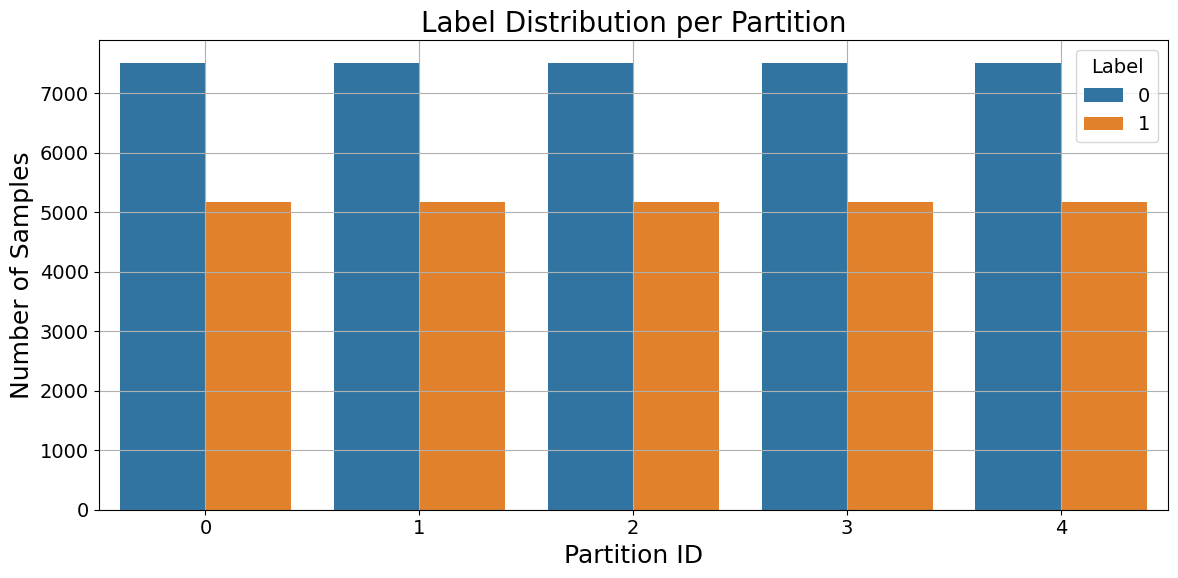

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
partition_df = get_partition_df(all_images, labels, num_partitions=5)
plot_label_distribution(partition_df)


In [ ]:
partition_df

,partition_id,label,count
0,0,0,7513
1,0,1,5172
2,1,0,7513
3,1,1,5172
4,2,0,7513
5,2,1,5172
6,3,0,7513
7,3,1,5172
8,4,0,7512
9,4,1,5173


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Statistics for Number of Examples per Partition

In [ ]:
partition_df.sum(1).describe()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,0
count,10.000000
mean,6345.000000
std,1233.078442
min,5173.000000
25%,5175.250000
50%,6345.500000
75%,7514.750000
max,7516.000000


### Calculate Mean Number of Updates Per Round

In [ ]:
(partition_df.sum(1) / BATCH_SIZE).apply(np.ceil)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,0
0,118.0
1,81.0
2,118.0
3,81.0
4,118.0
5,81.0
6,118.0
7,81.0
8,118.0
9,81.0


## Model training/evaluation (PyTorch)

In [ ]:
class MLPNet(nn.Module):
    def __init__(self) -> None:
        super(MLPNet, self).__init__()
        # self.conv_layers = nn.Sequential(
        #     nn.Conv2d(1, 16, kernel_size=3, padding=1),   # 1 input channel (grayscale), 16 output
        #     nn.ReLU(),
        #     nn.MaxPool2d(2, 2),  # 64x64

        #     nn.Conv2d(16, 32, kernel_size=3, padding=1),
        #     nn.ReLU(),
        #     nn.MaxPool2d(2, 2),  # 32x32
        # )
        self.fc_layers = nn.Sequential(
            nn.Linear(32*32 , 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),   # Binary classification: output logit
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.softmax(self.layer3(x))
        return x

class KANNet(PureKAN):
    def __init__(self) -> None:
        super().__init__([32*32 , 24, 24, 1])

    def forward(self, x):
        # Flatten the input for KAN
        x = x.view(x.size(0), -1)
        return super().forward(x)

class FastKANNet(FastKAN):
    def __init__(self) -> None:
        super().__init__([32*32, 24, 24, 1])

    def forward(self, x):
        # Flatten the input for KAN
        x = x.view(x.size(0), -1)
        return super().forward(x)

def create_network(net_type: str):
    if net_type == "mlp":
        return MLPNet()
    elif net_type == "kan":
        return KANNet()
    elif net_type == "fastkan":
        return FastKANNet()
    else:
        raise ValueError(f"Unknown network type: {net_type}")

def get_parameters(net) -> List[np.ndarray]:
    return [val.cpu().numpy() for _, val in net.state_dict().items()]


def set_parameters(net, parameters: List[np.ndarray]):
    params_dict = zip(net.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
    net.load_state_dict(state_dict, strict=True)

def get_model_size_in_MB(parameters):
    total_bytes = 0
    for param in parameters:
        total_bytes += param.size * param.itemsize  # num elements * bytes per element
    return total_bytes / (1024 * 1024)  # Convert to MB


def train(net, trainloader, epochs: int):
    """Train the network on the training set."""
    criterion = torch.nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(
        net.parameters(),
        lr=LEARNING_RATE,
        momentum=MOMENTUM)
    net.train()
    for epoch in range(epochs):
        correct, total, epoch_loss = 0, 0, 0.0
        for batch in trainloader:
            images, labels = batch["image"], batch["label"]
            images, labels = images.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(net(images), labels)
            loss.backward()
            optimizer.step()
            # Metrics
            epoch_loss += loss
            total += labels.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct += (predicted == labels).sum().item()
        epoch_loss /= len(trainloader.dataset)
        epoch_acc = correct / total
        print(f"Epoch {epoch+1}: train loss {epoch_loss}, accuracy {epoch_acc}")
        return epoch_loss, epoch_acc


def test(net, testloader):
    """Evaluate the network on the entire test set."""
    criterion = torch.nn.BCEWithLogitsLoss()
    correct, total, loss = 0, 0, 0.0
    net.eval()
    with torch.no_grad():
        for batch in testloader:
            images, labels = batch["image"], batch["label"]
            images, labels = images.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1)
            outputs = net(images)
            loss += criterion(outputs, labels).item()
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    loss /= len(testloader.dataset)
    accuracy = correct / total
    return loss, accuracy

## Flower Architecture

### Flower client

In [ ]:
class FlowerClient(NumPyClient):
    def __init__(self, pid, net, trainloader, valloader=None):
        self.pid = pid  # partition ID of a client
        self.net = net
        self.trainloader = trainloader
        self.valloader = valloader

    def get_parameters(self, config):
        print(f"[Client {self.pid}] get_parameters")
        return get_parameters(self.net)

    def fit(self, parameters, config):
        # Read values from config
        server_round = config["server_round"]
        local_epochs = config["local_epochs"]

        # Use values provided by the config
        print(f"[Client {self.pid}, round {server_round}] fit, config: {config}")
        set_parameters(self.net, parameters)
        epoch_loss, epoch_accuracy = train(self.net, self.trainloader, epochs=local_epochs)
        return get_parameters(self.net), len(self.trainloader), {"epoch_loss": float(epoch_loss),
                                                                 "epoch_accuracy": float(epoch_accuracy)}

    def evaluate(self, parameters, config):
        print(f"[Client {self.pid}] evaluate, config: {config}")
        set_parameters(self.net, parameters)
        loss, accuracy = test(self.net, self.valloader)
        return float(loss), len(self.valloader), {"accuracy": float(accuracy)}


def client_fn(context: Context) -> Client:
    net = create_network(NET_TYPE).to(DEVICE)
    partition_id = context.node_config["partition-id"]
    num_partitions = context.node_config["num-partitions"]
    trainloader, _ = load_datasets(partition_id, num_partitions)
    return FlowerClient(partition_id, net, trainloader).to_client()

### Server-side parameter **evaluation**

#### Save evaluation results

In [ ]:
def create_new_history():
    history = {"net_type": NET_TYPE,
              "test_accuracy": [],
              "test_loss": [],
              "train_accuracy": [0.0], # No fit metrics before the first round
              "train_loss": [0.0],
              "execution_time": 0,
              "seed": SEED,
              "batch_size": BATCH_SIZE,
              "local_epochs": LOCAL_EPOCHS,
              "fraction_clients": FRACTION_CLIENTS,
              "comm_rounds": COMM_ROUNDS,
              "num_partitions": NUM_PARTITIONS,
              "device": str(DEVICE),
              "learning_rate": LEARNING_RATE,
              "momentum": MOMENTUM,
              "Communication_sizes": [],
              }
    return history

# Need to use a global var because we can't pass our dictionary as argument
def save_test_metrics(server_round: int, accuracy: float, loss: float, model_size: float):
    HISTORY["test_accuracy"].append((accuracy, server_round))
    HISTORY["test_loss"].append((loss, server_round))
    HISTORY["Communication_sizes"].append((model_size, server_round))

# Currently can't capture the server round inside the fit aggregation function
def save_train_metrics(accuracy: float, loss: float):
    HISTORY["train_accuracy"].append(accuracy)
    HISTORY["train_loss"].append(loss)

def save_execution_time(execution_time: float):
    HISTORY["execution_time"] = execution_time

#### Evaluation function

In [ ]:
# The `evaluate` function will be called by Flower after every round
def evaluate(
    server_round: int,
    parameters: NDArrays,
    config: Dict[str, Scalar],
) -> Optional[Tuple[float, Dict[str, Scalar]]]:
    net = create_network(NET_TYPE).to(DEVICE)
    _, testloader = load_datasets(0, NUM_PARTITIONS)
    model_size = get_model_size_in_MB(parameters)
    set_parameters(net, parameters)  # Update model with the latest parameters
    loss, accuracy = test(net, testloader)
    print(f"Server-side evaluation loss {loss} / accuracy {accuracy} / Communication cost {model_size}")
    save_test_metrics(server_round, accuracy, loss, model_size)
    return loss, {"accuracy": accuracy}

### Training **Configuration** (e.g. epochs)




In [ ]:
def fit_config(server_round: int):
    """Return training configuration dict for each round.

    """
    config = {
        "server_round": server_round,  # The current round of federated learning
        "local_epochs": LOCAL_EPOCHS,
    }
    return config

### Flower **Server**

#### Fit (training) Metrics Aggregation

In [ ]:
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    """Inspired by https://github.com/adap/flower/blob/0e7c1b06c32ab90e0d3cf64825ed51eedd715509/examples/custom-mods/server.py"""

    # Get number of examples for each client used for training
    examples = [num_examples for num_examples, _ in metrics]

    # Multiply accuracy of each client by number of examples used
    train_losses = [
        num_examples * float(m["epoch_loss"]) for num_examples, m in metrics
    ]
    train_accuracies = [
        num_examples * float(m["epoch_accuracy"]) for num_examples, m in metrics
    ]

    train_loss = sum(train_losses) / sum(examples)
    train_accuracy = sum(train_accuracies) / sum(examples)

    save_train_metrics(train_accuracy, train_loss)

    # Aggregate and return custom metric (weighted average)
    return {
        "train_loss": sum(train_losses) / sum(examples),
        "train_accuracy": sum(train_accuracies) / sum(examples),
    }

#### Server function

In [ ]:
def server_fn(context: Context) -> ServerAppComponents:
    # Create FedAvg strategy
    strategy = FedAvg(
        fraction_fit=FRACTION_CLIENTS,
        fraction_evaluate=0,
        min_fit_clients=1,
        min_evaluate_clients=0,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        evaluate_fn=evaluate,
        on_fit_config_fn=fit_config,
        fit_metrics_aggregation_fn=weighted_average,
    )

    config = ServerConfig(num_rounds=COMM_ROUNDS)
    return ServerAppComponents(strategy=strategy, config=config)

## Helpers

### Get simulation execution time from Flower logs

In [ ]:
def get_elapsed_time(log_filepath) -> float:
    with open(log_filepath, 'r') as f:
        log_content = f.read()

        pattern = r'Run finished \d+ round\(s\) in (\d+\.\d+)s'
        regex_match = re.search(pattern, log_content)

        if regex_match:
            elapsed_time = float(regex_match.group(1))
            print(f"Simulation execution time: {elapsed_time} seconds")
            return elapsed_time
        else:
            print("Could not find elapsed time.")
            return None

## Simulation

### Global model **initialization**

In [ ]:
# Create an instance of the model and get the parameters
initial_model = create_network(NET_TYPE)
params = get_parameters(initial_model)
total_params = sum(p.numel() for p in initial_model.parameters() if p.requires_grad)
print(f"Total number of parameters: {total_params}")

Total number of parameters: 228777


In [ ]:
params = get_parameters(initial_model)
sizes = []

for param in params:
  sizes.append(param.size * param.itemsize, )  # num elements * bytes per element
total_bytes = sum(sizes)
print("Total Size :", total_bytes / (1024 * 1024))  # Convert to MB

Total Size : 0.8728065490722656


### Run Simulation

In [ ]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


### Serialize Results and Save to Google Drive

In [ ]:
# Define hardware resources
if DEVICE.type == "cuda":
    backend_config = {"client_resources": {"num_gpus": 0.25, "num_cpus": 2}}
else:
    backend_config = {"num_cpus": 2}

# backend_config = {"num_cpus": 2}

# NET_TYPE = ["mlp", kan]

# Create Apps
client = ClientApp(client_fn=client_fn)
server = ServerApp(server_fn=server_fn)

# create new history
HISTORY = create_new_history()

# Configure logs
log_id = f"log_{NET_TYPE}_seed_{SEED}"
log_filename = f"{log_id}.txt"
flwr.common.logger.configure(
    identifier=log_id,
    filename=log_filename)

# Run simulation
run_simulation(
    server_app=server,
    client_app=client,
    num_supernodes=NUM_PARTITIONS,
    backend_config=backend_config,
)

save_execution_time(get_elapsed_time(log_filename))

INFO :      Starting Flower ServerApp, config: num_rounds=100, no round_timeout
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.023933476819766788, {'accuracy': 0.5039370078740157}
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :     

Server-side evaluation loss 0.023933476819766788 / accuracy 0.5039370078740157 / Communication cost 0.8728065490722656


(pid=44254) 2025-10-17 08:43:00.437092: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=44254) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=44254) E0000 00:00:1760690580.456330   44254 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=44254) E0000 00:00:1760690580.462309   44254 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=44254) W0000 00:00:1760690580.480174   44254 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
(pid=44254) W0000 00:00:1760690580.480203   44254 computation_placer.cc:177] computation placer already registered.

(ClientAppActor pid=44254) [Client 0, round 1] fit, config: {'server_round': 1, 'local_epochs': 5}
(ClientAppActor pid=44254) Epoch 1: train loss 0.025804918259382248, accuracy 0.4881889763779528
(ClientAppActor pid=44254) [Client 22, round 1] fit, config: {'server_round': 1, 'local_epochs': 5}


(ClientAppActor pid=44254) /tmp/ipython-input-560303732.py:21: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
(ClientAppActor pid=44254) Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      fit progress: (100, 0.005391591543874402, {'accuracy': 0.9212598425196851}, 1018.8719885669998)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 100 round(s) in 1018.87s
INFO :      	History (loss, centralized):
INFO :      		round 0: 0.023933476819766788
INFO :      		round 1: 0.021627639691660722
INFO :      		round 2: 0.020936751459527204
INFO :      		round 3: 0.018963925481781246
INFO :      		round 4: 0.018878318662718524
INFO :      		round 5: 0.017158028882319532
INFO :      		round 6: 0.016144496718729574
INFO :      		round 7: 0.015868801770247812
INFO :      		round

Server-side evaluation loss 0.005391591543874402 / accuracy 0.9212598425196851 / Communication cost 0.8728065490722656


INFO :      	                (17, 0.013211818132549524),
INFO :      	                (18, 0.012103477865457535),
INFO :      	                (19, 0.011715590581297874),
INFO :      	                (20, 0.010597298759967089),
INFO :      	                (21, 0.011442016810178757),
INFO :      	                (22, 0.01123694609850645),
INFO :      	                (23, 0.010111630149185657),
INFO :      	                (24, 0.009831385267898441),
INFO :      	                (25, 0.008644683053717017),
INFO :      	                (26, 0.009018910909071564),
INFO :      	                (27, 0.009821244049817324),
INFO :      	                (28, 0.008872065320611),
INFO :      	                (29, 0.008682276308536529),
INFO :      	                (30, 0.007317544799298048),
INFO :      	                (31, 0.00855535501614213),
INFO :      	                (32, 0.00779960323125124),
INFO :      	                (33, 0.007603280665352941),
INFO :      	                (34, 0.0

Simulation execution time: 1002.73 seconds


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
params = get_parameters(initial_model)
total_params = sum(p.numel() for p in initial_model.parameters() if p.requires_grad)
print(f"Total number of parameters: {total_params}")

Total number of parameters: 228777


In [ ]:
folder = "/content/drive/MyDrive/FL_results/fedkan_mri_dataset_results/"
filename = f"hist_{NET_TYPE}_s{SEED}_r{COMM_ROUNDS}_{str(DEVICE)}_WithoutLinear.json"
filepath = folder + filename
print(f"Saving to {filepath}")

Saving to /content/drive/MyDrive/FL_results/fedkan_mri_dataset_results/hist_fastkan_s249_r100_cuda_WithoutLinear.json


In [ ]:
# import os
# import json

# # Extract directory part of the path
# dir_path = os.path.dirname(filepath)

# # Create the directory if it doesn't exist
# os.makedirs(dir_path, exist_ok=True)

with open(filepath, 'w') as f:
    json.dump(HISTORY, f, indent=4)

In [ ]:
with open(filepath, 'r') as f:
    x = json.load(f)
x

{'net_type': 'fastkan',
 'test_accuracy': [[0.5039370078740157, 0],
  [0.5511811023622047, 1],
  [0.5905511811023622, 2],
  [0.7086614173228346, 3],
  [0.6456692913385826, 4],
  [0.7480314960629921, 5],
  [0.7795275590551181, 6],
  [0.7322834645669292, 7],
  [0.7716535433070866, 8],
  [0.7952755905511811, 9],
  [0.7874015748031497, 10],
  [0.7874015748031497, 11],
  [0.7165354330708661, 12],
  [0.7874015748031497, 13],
  [0.7716535433070866, 14],
  [0.7637795275590551, 15],
  [0.8031496062992126, 16],
  [0.8267716535433071, 17],
  [0.7874015748031497, 18],
  [0.8267716535433071, 19],
  [0.7952755905511811, 20],
  [0.7952755905511811, 21],
  [0.8582677165354331, 22],
  [0.8740157480314961, 23],
  [0.8740157480314961, 24],
  [0.8818897637795275, 25],
  [0.889763779527559, 26],
  [0.8503937007874016, 27],
  [0.8582677165354331, 28],
  [0.84251968503937, 29],
  [0.8661417322834646, 30],
  [0.8976377952755905, 31],
  [0.905511811023622, 32],
  [0.8740157480314961, 33],
  [0.8582677165354331

## Plot all results

### Gather JSON data from Google Drive

In [ ]:
folder = "/content/drive/MyDrive/FL_results/fedkan_mri_dataset_results/"
#folder = "/content/drive/MyDrive/LXAI_FedKAN_Data/"

# Get a list of all JSON files in the folder
json_files = [f for f in os.listdir(folder) if f.endswith('.json')]

# Initialize separate lists for 'kan' and 'mlp' data
kan_data = []
mlp_data = []
fastkan_data = []

# Load and separate the data based on 'net_type'
for json_file in json_files:
    with open(os.path.join(folder, json_file), 'r') as f:
        data = json.load(f)
        if data['net_type'] == 'kan':
            kan_data.append(data)
        elif data['net_type'] == 'mlp':
            mlp_data.append(data)
        elif data['net_type'] == 'fastkan':
            fastkan_data.append(data)

In [ ]:
print(f"Number of files: {len(json_files)}")
print(f"Number of 'kan' files: {len(kan_data)}")
print(f"Number of 'mlp' files: {len(mlp_data)}")
print(f"Number of 'fastkan' files: {len(fastkan_data)}")

Number of files: 3
Number of 'kan' files: 1
Number of 'mlp' files: 0
Number of 'fastkan' files: 2


### Extract metrics and hyperparameters from each execution

In [ ]:
def aggregate_data(data_list):
    """ Aggregate metrics for a given list of JSON data """
    train_accuracies = []
    test_accuracies = []
    train_losses = []
    test_losses = []
    execution_times = []
    communication_sizes =[]

    for data in data_list:
        train_accuracies.append([acc for acc in data['train_accuracy'][1:]])  # Skip the first element
        test_accuracies.append([acc[0] for acc in data['test_accuracy'][1:]])  # Skip the first element
        train_losses.append([loss for loss in data['train_loss'][1:]])  # Skip the first element
        test_losses.append([loss[0] for loss in data['test_loss'][1:]])  # Skip the first element
        execution_times.append(data['execution_time'])
        communication_sizes.append([size[0] for size in data['Communication_sizes'][1:]])  # Skip the first element

    # Convert lists to numpy arrays for easier aggregation
    train_accuracies = np.array(train_accuracies)
    test_accuracies = np.array(test_accuracies)
    train_losses = np.array(train_losses)
    test_losses = np.array(test_losses)
    execution_times = np.array(execution_times)
    communication_sizes = np.array(communication_sizes)

    # Calculate means and standard deviations
    train_acc_mean = np.mean(train_accuracies, axis=0)
    train_acc_std = np.std(train_accuracies, axis=0)

    test_acc_mean = np.mean(test_accuracies, axis=0)
    test_acc_std = np.std(test_accuracies, axis=0)

    train_loss_mean = np.mean(train_losses, axis=0)
    train_loss_std = np.std(train_losses, axis=0)

    test_loss_mean = np.mean(test_losses, axis=0)
    test_loss_std = np.std(test_losses, axis=0)

    execution_time_mean = np.mean(execution_times)
    execution_time_std = np.std(execution_times)

    communication_size_mean = np.mean(communication_sizes, axis=0)
    communication_size_std = np.std(communication_sizes, axis=0)

    return train_acc_mean, train_acc_std, test_acc_mean, test_acc_std, train_loss_mean, train_loss_std, test_loss_mean, test_loss_std, execution_time_mean, execution_time_std, communication_size_mean, communication_size_std

# Aggregate data for 'kan's and 'mlp'
kan_results = aggregate_data(kan_data)
mlp_results = aggregate_data(mlp_data)
fastkan_results = aggregate_data(fastkan_data)

# Assuming all gathered simulation had the same hyperparameters
hyperparameters = (f"lr={kan_data[0]['learning_rate']}, bs={kan_data[0]['batch_size']}, "
                  f"epochs={kan_data[0]['local_epochs']}, frac={kan_data[0]['fraction_clients']}")

# Define the communication rounds (assuming all files have the same number of rounds)
comm_rounds = list(range(1, len(kan_results[0]) + 1))

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Normalized Data:
Spline-KAN: [0.55681115 0.10000003 0.10000003]
RBF-KAN: [0.89999996 0.32936185 0.60634148]
MLP: [0.1 0.9 0.9]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


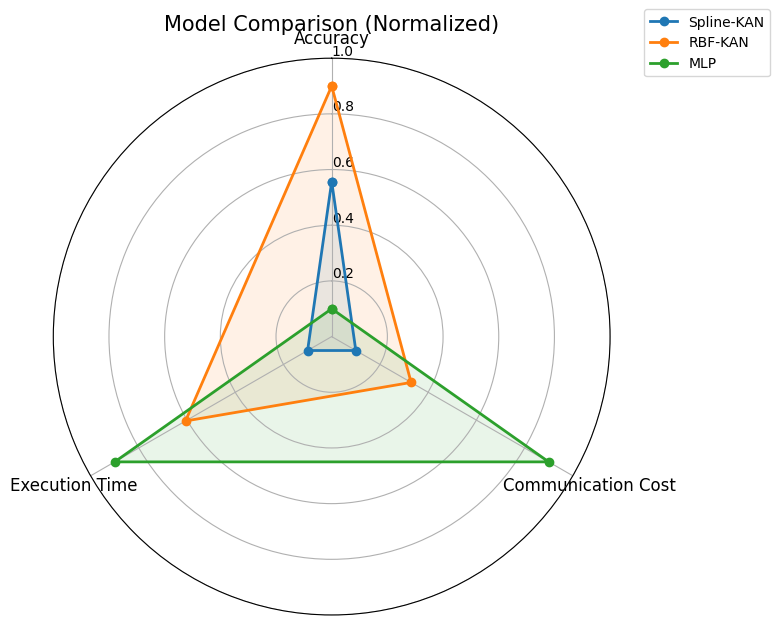

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Raw values (your actual data may differ)
models = ['Spline-KAN', 'RBF-KAN', 'MLP']
accuracy = [0.8267, 0.9213, 0.70078]
comm_cost = [0.6729, 0.5817, 0.3548]  # MB
exec_time = [0.8849, 0.7292, 0.6389]  # sec

# Normalization function
def normalize(arr, inverse=False):
    eps = 1e-8
    norm = (arr - np.min(arr)) / (np.max(arr) - np.min(arr) + eps)
    norm = 0.1 + norm * 0.8  # Map from [0, 1] → [0.1, 0.9]
    return 1 - norm if inverse else norm

# Normalize metrics
normalized_data = np.array([
    normalize(accuracy),                  # Accuracy (higher is better)
    normalize(comm_cost, inverse=True),   # Lower is better
    normalize(exec_time, inverse=True)    # Lower is better
])

# Transpose: rows = models, cols = metrics
data = normalized_data.T

# Radar chart setup
labels = ['Accuracy', 'Communication Cost', 'Execution Time']
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each model
for i, model in enumerate(models):
    values = data[i].tolist()
    values += values[:1]  # close the loop
    ax.plot(angles, values, label=model, marker='o', linewidth=2)
    ax.fill(angles, values, alpha=0.1)

print("Normalized Data:")
for i, model in enumerate(models):
    print(f"{model}: {data[i]}")

# Customize
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rlabel_position(0)
ax.set_ylim(0, 1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12)

# Title & Legend
ax.set_title('Model Comparison (Normalized)', size=15, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()


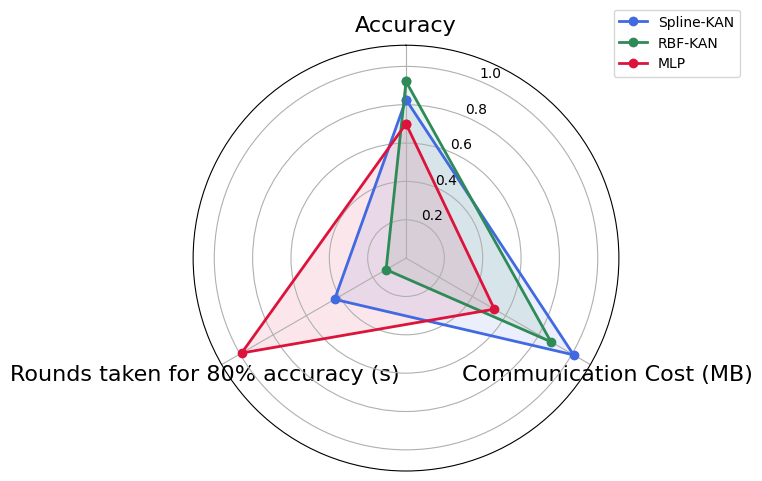

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Raw values
models = ['Spline-KAN', 'RBF-KAN', 'MLP']
accuracy = [0.8267, 0.9213, 0.70078]
comm_cost = [1.0094, 0.8728, 0.5322]  # MB
exec_time = [0.43, 0.12, 0.99]  # sec

# Combine metrics into a matrix (rows = models, columns = metrics)
data = np.array([
    [accuracy[0], comm_cost[0], exec_time[0]],
    [accuracy[1], comm_cost[1], exec_time[1]],
    [accuracy[2], comm_cost[2], exec_time[2]]
])

# Radar chart setup
labels = ['Accuracy', 'Communication Cost (MB)', 'Rounds taken for 80% accuracy (s)']
num_vars = len(labels)

# Calculate angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # complete the loop

# Define custom colors for each model
color_map = {
    'Spline-KAN': 'royalblue',
    'RBF-KAN': 'seagreen',
    'MLP': 'crimson'
}

# Create plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each model
for i, model in enumerate(models):
    values = data[i].tolist()
    values += values[:1]  # close the loop\
    color = color_map[model]
    ax.plot(angles, values, label=model, marker='o', linewidth=2, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

# Customization
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=16)
ax.set_title('', size=16, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Adjust r-axis scale to accommodate all metrics
max_vals = np.max(data, axis=0)
ax.set_ylim(0, max(max_vals) * 1.1)  # set limit based on largest metric value

plt.tight_layout()
plt.show()


In [ ]:
kan_results[0].

array([0.55549007, 0.59341813, 0.59365109, 0.59282603, 0.59357072,
       0.59522822, 0.60094543, 0.61053208, 0.62684737, 0.6209271 ,
       0.64216442, 0.64103768, 0.66048976, 0.65904502, 0.65976215,
       0.6678501 , 0.66850277, 0.67876462, 0.6646341 , 0.67771203,
       0.67718593, 0.68230132, 0.67185738, 0.69091848, 0.6825634 ,
       0.70716621, 0.68040543, 0.69788357, 0.69761178, 0.68836603,
       0.69023513, 0.71603884, 0.70177515, 0.7157558 , 0.70667777,
       0.72293094, 0.71772158, 0.7160039 , 0.70517363, 0.70924614,
       0.72056834, 0.71760899, 0.73841339, 0.71865614, 0.72847497,
       0.73895619, 0.73206681, 0.72995232, 0.73487979, 0.74620743,
       0.7408847 , 0.73146306, 0.74370351, 0.73822664, 0.73363657,
       0.7438856 , 0.74452274, 0.7473563 , 0.75645801, 0.75315854,
       0.75689792, 0.76108807, 0.75449067, 0.75965732, 0.74695872,
       0.76656688, 0.76128104, 0.76459644, 0.76458867, 0.76350192,
       0.76692564, 0.76980113, 0.77164811, 0.77839848, 0.76297

### Plot all Metrics

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 14,         # base font size
    'axes.titlesize': 20,    # title font size
    'axes.labelsize': 18,    # x and y label size
    'xtick.labelsize': 14,   # x tick label size
    'ytick.labelsize': 14,   # y tick label size
    'legend.fontsize': 14,   # legend font size
})


In [ ]:
print(len(mlp_results))

12


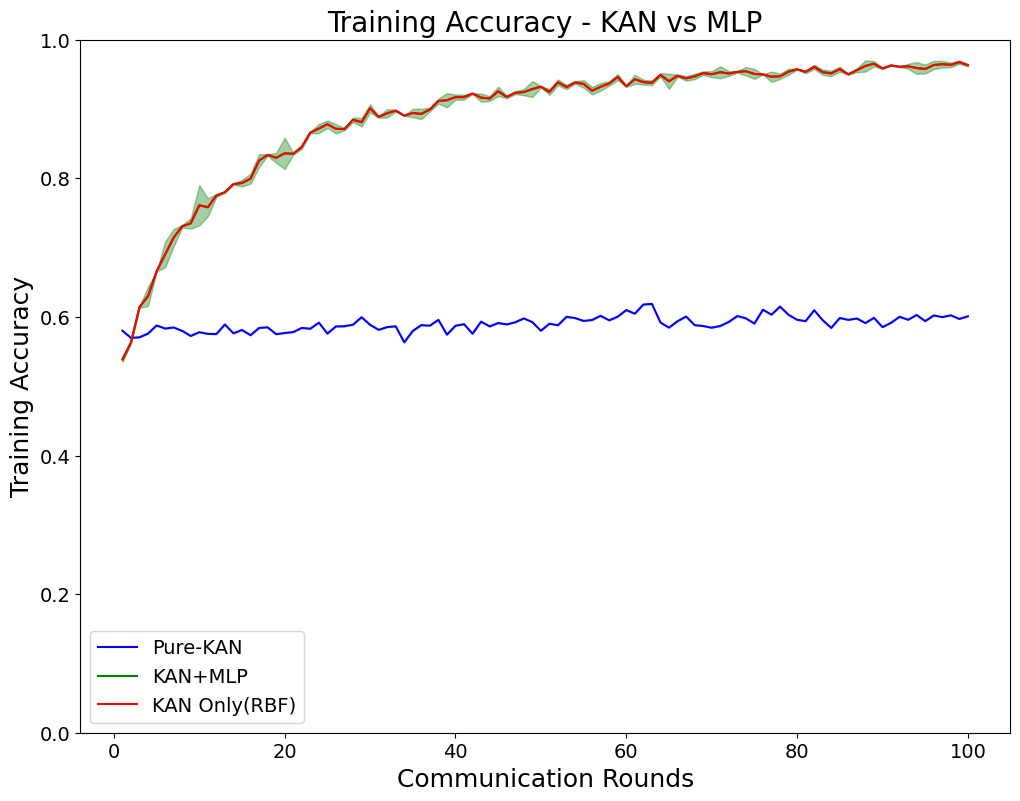

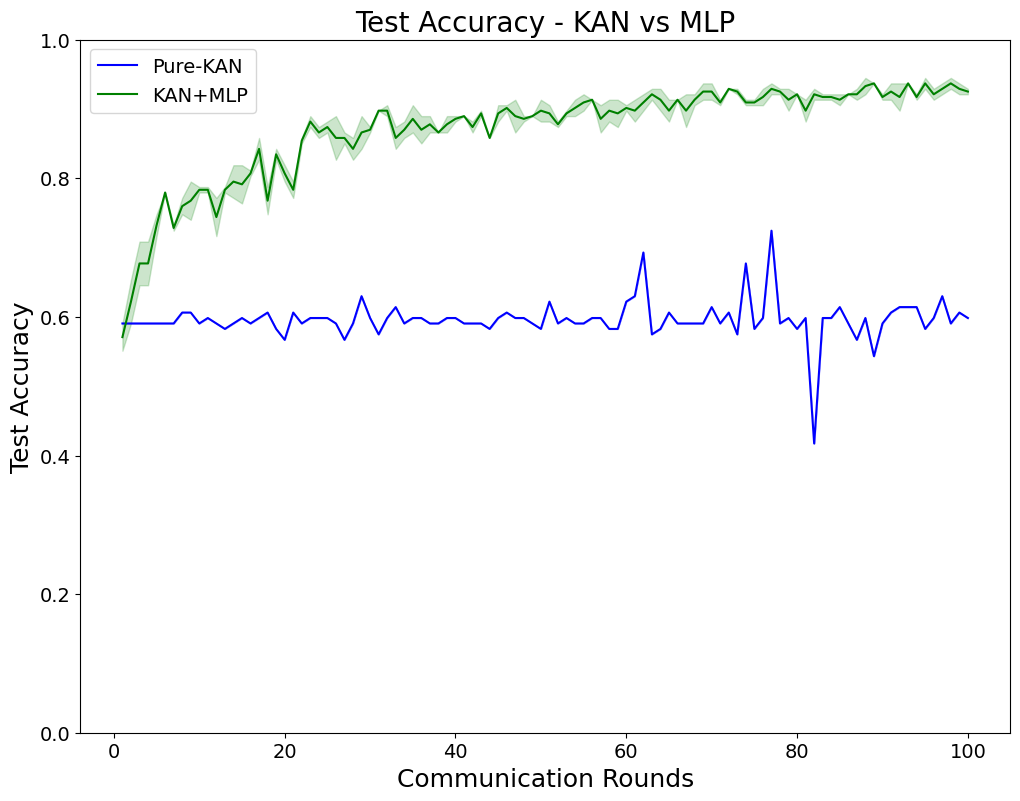

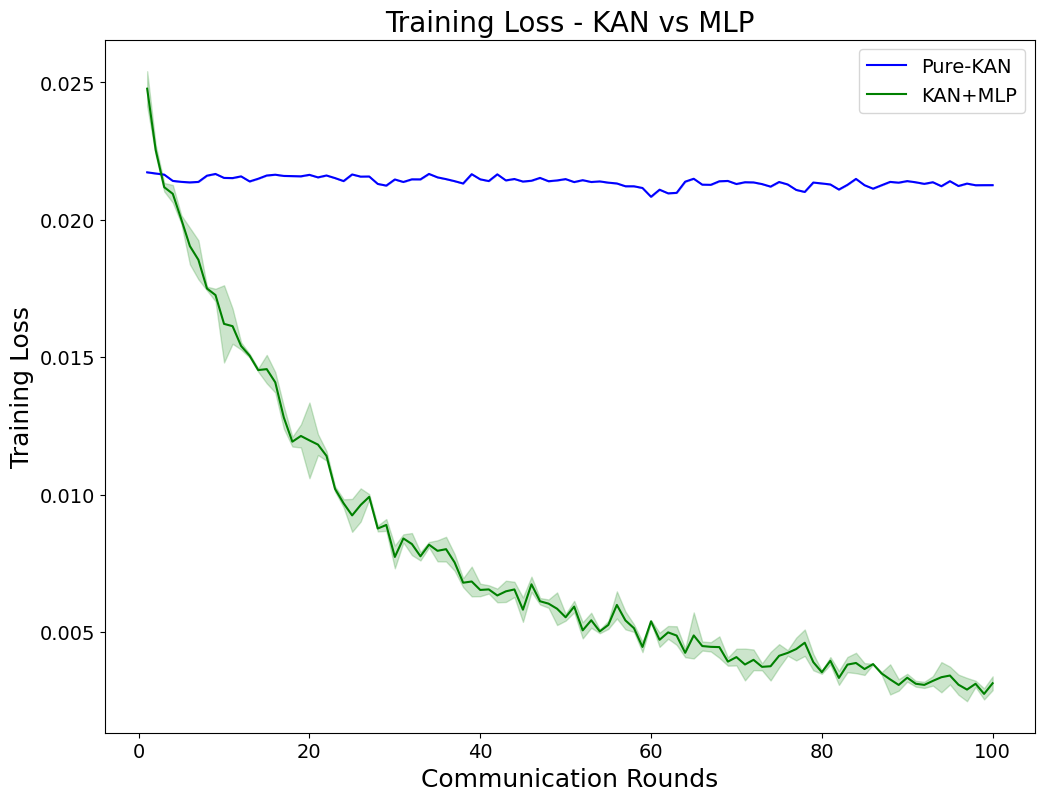

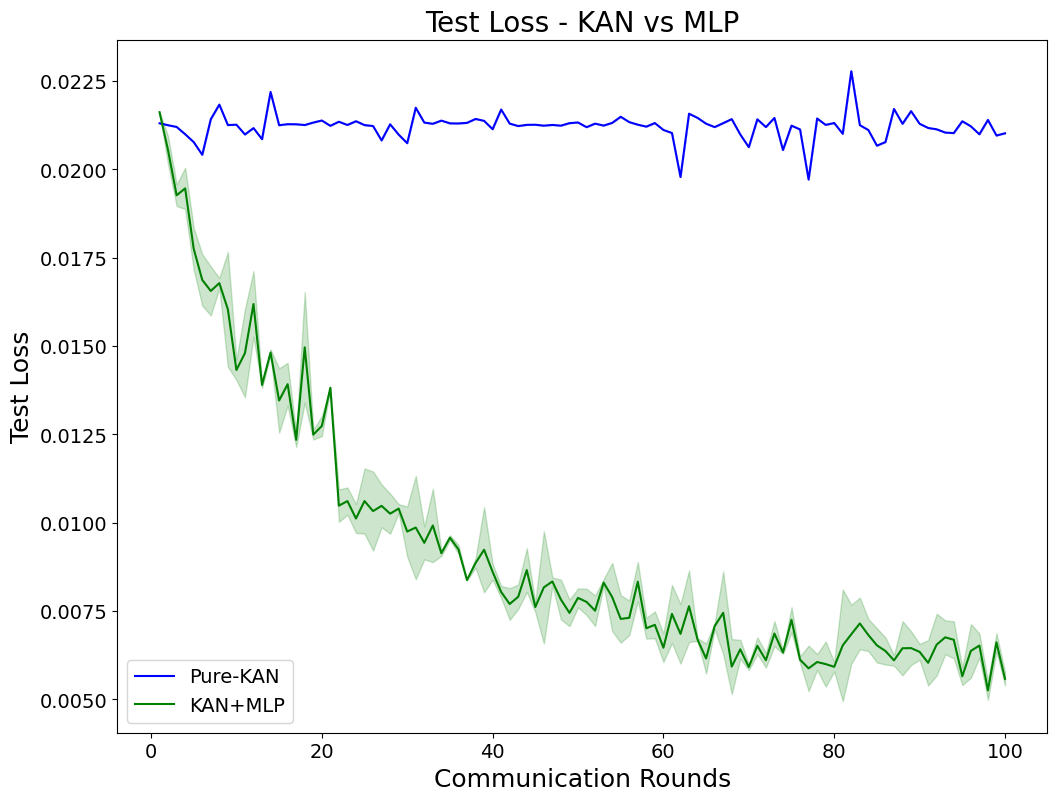

In [ ]:
figsize=(12, 9)

# Plot Training Accuracy with error bands for 'kan' and 'mlp'
plt.figure(figsize=figsize)

plt.plot(comm_rounds, kan_results[0], 'b-', label='Pure-KAN')
plt.fill_between(comm_rounds, kan_results[0] - kan_results[1], kan_results[0] + kan_results[1], color='b', alpha=0.2)

# plt.plot(comm_rounds, mlp_results[0], 'r-', label='MLP')
# plt.fill_between(comm_rounds, mlp_results[0] - mlp_results[1], mlp_results[0] + mlp_results[1], color='r', alpha=0.2)

plt.plot(comm_rounds, fastkan_results[0], 'g-', label='KAN+MLP')
plt.fill_between(comm_rounds, fastkan_results[0] - fastkan_results[1], fastkan_results[0] + fastkan_results[1], color='g', alpha=0.2)

plt.plot(comm_rounds, fastkan_results[0], 'r-', label='KAN Only(RBF)')
plt.fill_between(comm_rounds, fastkan_results[0] - fastkan_results[1], fastkan_results[0] + fastkan_results[1], color='g', alpha=0.2)

plt.title(f"Training Accuracy - KAN vs MLP")
plt.xlabel("Communication Rounds")
plt.ylabel("Training Accuracy")
plt.ylim(0, 1)
# plt.xticks(comm_rounds)
plt.legend()
plt.show()

# Plot Test Accuracy with error bands for 'kan' and 'mlp'
plt.figure(figsize=figsize)

plt.plot(comm_rounds, kan_results[2], 'b-', label='Pure-KAN')
plt.fill_between(comm_rounds, kan_results[2] - kan_results[3], kan_results[2] + kan_results[3], color='b', alpha=0.2)

# plt.plot(comm_rounds, mlp_results[2], 'r-', label='MLP')
# plt.fill_between(comm_rounds, mlp_results[2] - mlp_results[3], mlp_results[2] + mlp_results[3], color='r', alpha=0.2)

plt.plot(comm_rounds, fastkan_results[2], 'g-', label='KAN+MLP')
plt.fill_between(comm_rounds, fastkan_results[2] - fastkan_results[3], fastkan_results[2] + fastkan_results[3], color='g', alpha=0.2)



plt.title(f"Test Accuracy - KAN vs MLP")
plt.xlabel("Communication Rounds")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
# plt.xticks(comm_rounds)
plt.legend()
plt.show()

# Plot Training Loss with error bands for 'kan' and 'mlp'
plt.figure(figsize=figsize)

plt.plot(comm_rounds, kan_results[4], 'b-', label='Pure-KAN')
plt.fill_between(comm_rounds, kan_results[4] - kan_results[5], kan_results[4] + kan_results[5], color='b', alpha=0.2)

# plt.plot(comm_rounds, mlp_results[4], 'r-', label='MLP')
# plt.fill_between(comm_rounds, mlp_results[4] - mlp_results[5], mlp_results[4] + mlp_results[5], color='r', alpha=0.2)

plt.plot(comm_rounds, fastkan_results[4], 'g-', label='KAN+MLP')
plt.fill_between(comm_rounds, fastkan_results[4] - fastkan_results[5], fastkan_results[4] + fastkan_results[5], color='g', alpha=0.2)

plt.title(f"Training Loss - KAN vs MLP")
plt.xlabel("Communication Rounds")
plt.ylabel("Training Loss")
# plt.xticks(comm_rounds)
plt.legend()
plt.show()

# Plot Test Loss with error bands for 'kan' and 'mlp'
plt.figure(figsize=figsize)

plt.plot(comm_rounds, kan_results[6], 'b-', label='Pure-KAN')
plt.fill_between(comm_rounds, kan_results[6] - kan_results[7], kan_results[6] + kan_results[7], color='b', alpha=0.2)

# plt.plot(comm_rounds, mlp_results[6], 'r-', label='MLP')
# plt.fill_between(comm_rounds, mlp_results[6] - mlp_results[7], mlp_results[6] + mlp_results[7], color='r', alpha=0.2)

plt.plot(comm_rounds, fastkan_results[6], 'g-', label='KAN+MLP')
plt.fill_between(comm_rounds, fastkan_results[6] - fastkan_results[7], fastkan_results[6] + fastkan_results[7], color='g', alpha=0.2)

plt.title(f"Test Loss - KAN vs MLP")
plt.xlabel("Communication Rounds")
plt.ylabel("Test Loss")
# plt.xticks(comm_rounds)
plt.legend()
plt.show()

#Communication Cost per Round (MLP vs KAN)

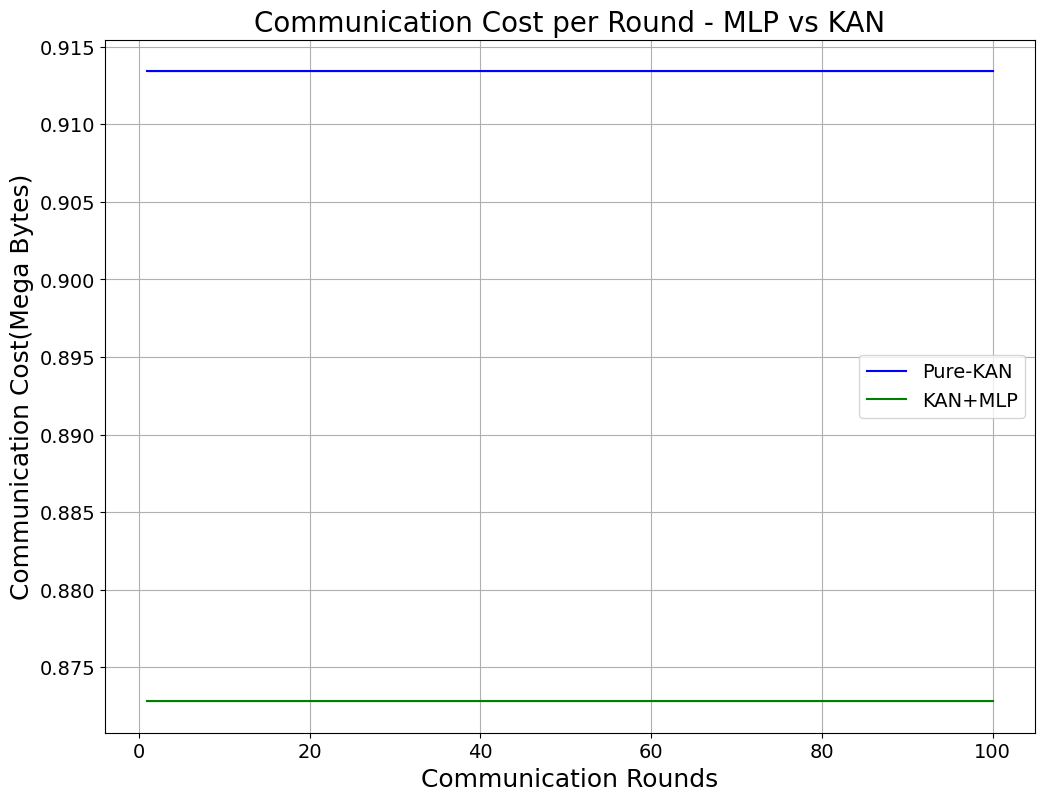

In [ ]:
plt.figure(figsize=figsize)

# Plot for Spline-KAN
plt.plot(comm_rounds, kan_results[10], 'b-', label='Pure-KAN')
plt.fill_between(comm_rounds, kan_results[10] - kan_results[11], kan_results[10] + kan_results[11], color='b', alpha=0.2)

# Plot for Spline-KAN
plt.plot(comm_rounds, fastkan_results[10], 'g-', label='KAN+MLP')
plt.fill_between(comm_rounds, fastkan_results[10] - fastkan_results[11], fastkan_results[10] + fastkan_results[11], color='g', alpha=0.2)

# Plot for MLP
# plt.plot(comm_rounds, mlp_results[10], 'r-', label='MLP')
# plt.fill_between(comm_rounds, mlp_results[10] - mlp_results[11], mlp_results[10] + mlp_results[11], color='r', alpha=0.2)

plt.title("Communication Cost per Round - MLP vs KAN")
plt.xlabel("Communication Rounds")
plt.ylabel("Communication Cost(Mega Bytes)")
plt.legend()
plt.grid(True)
plt.show()

#KAN: Accuracy vs Communication Rounds

In [ ]:
plt.figure(figsize=figsize)
plt.plot(comm_rounds, kan_results[0], 'b-', label='Train Accuracy')
plt.fill_between(comm_rounds, kan_results[0] - kan_results[1], kan_results[0] + kan_results[1], color='b', alpha=0.2)

plt.plot(comm_rounds, kan_results[2], 'c-', label='Test Accuracy')
plt.fill_between(comm_rounds, kan_results[2] - kan_results[3], kan_results[2] + kan_results[3], color='c', alpha=0.2)

plt.title("Spline-KAN: Accuracy vs Communication Rounds")
plt.xlabel("Communication Rounds")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.show()

#MLP: Accuracy vs Communication Rounds

In [ ]:
plt.figure(figsize=figsize)
plt.plot(comm_rounds, mlp_results[0], 'r-', label='Train Accuracy')
plt.fill_between(comm_rounds, mlp_results[0] - mlp_results[1], mlp_results[0] + mlp_results[1], color='r', alpha=0.2)

plt.plot(comm_rounds, mlp_results[2], 'm-', label='Test Accuracy')
plt.fill_between(comm_rounds, mlp_results[2] - mlp_results[3], mlp_results[2] + mlp_results[3], color='m', alpha=0.2)

plt.title("MLP: Accuracy vs Communication Rounds")
plt.xlabel("Communication Rounds")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.show()

#KAN: Loss vs Communication Rounds

In [ ]:
plt.figure(figsize=figsize)
plt.plot(comm_rounds, kan_results[4], 'b-', label='Train Loss')
plt.fill_between(comm_rounds, kan_results[4] - kan_results[5], kan_results[4] + kan_results[5], color='b', alpha=0.2)

plt.plot(comm_rounds, kan_results[6], 'c-', label='Test Loss')
plt.fill_between(comm_rounds, kan_results[6] - kan_results[7], kan_results[6] + kan_results[7], color='c', alpha=0.2)

plt.title("Spline-KAN: Loss vs Communication Rounds")
plt.xlabel("Communication Rounds")
plt.ylabel("Loss")
plt.legend()
plt.show()

#MLP: Loss vs Communication Rounds

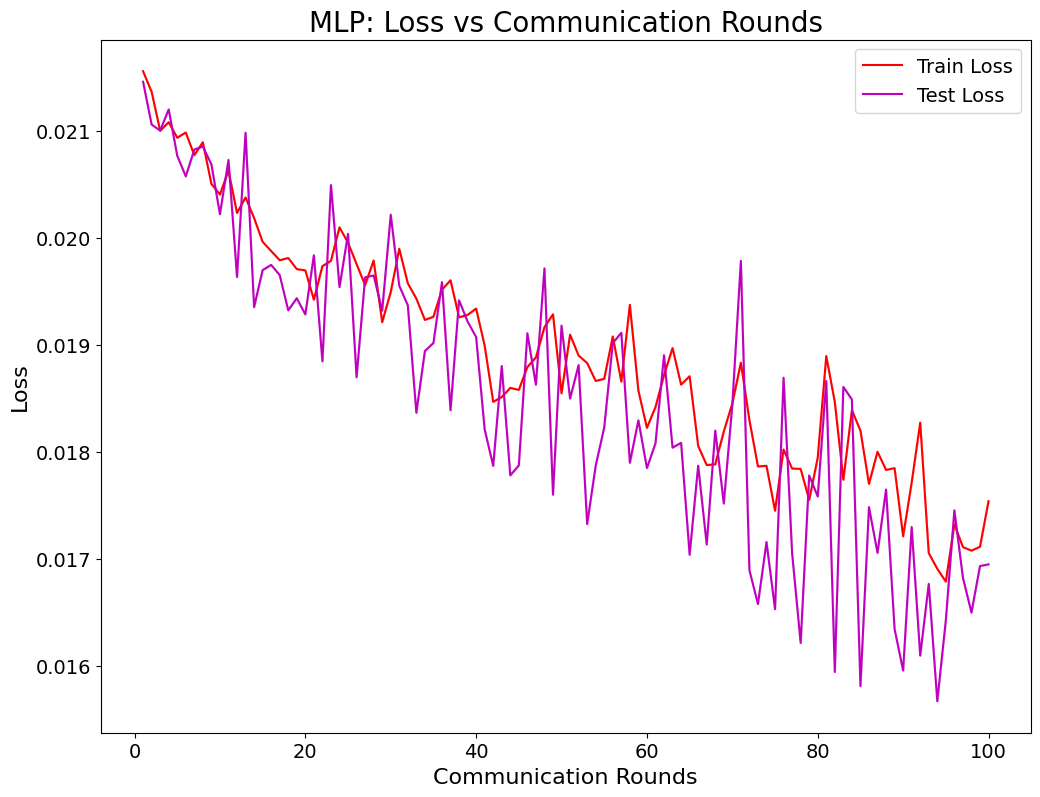

In [ ]:
plt.figure(figsize=figsize)
plt.plot(comm_rounds, mlp_results[4], 'r-', label='Train Loss')
plt.fill_between(comm_rounds, mlp_results[4] - mlp_results[5], mlp_results[4] + mlp_results[5], color='r', alpha=0.2)

plt.plot(comm_rounds, mlp_results[6], 'm-', label='Test Loss')
plt.fill_between(comm_rounds, mlp_results[6] - mlp_results[7], mlp_results[6] + mlp_results[7], color='m', alpha=0.2)

plt.title("MLP: Loss vs Communication Rounds")
plt.xlabel("Communication Rounds")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
print(f"Execution time for KAN: {kan_results[8]} ± {kan_results[9]} seconds")
print(f"Execution time for MLP: {mlp_results[8]} ± {mlp_results[9]} seconds")
print(f"Execution time for FastKAN: {fastkan_results[8]} ± {fastkan_results[9]} seconds")


## Hypothesis Testing

### Convert to Pandas Dataframe and Process Data

In [ ]:
import pandas as pd
df_kan = pd.DataFrame(kan_data)
df_mlp = pd.DataFrame(mlp_data)
df_fastkan = pd.DataFrame(fastkan_data)

In [ ]:
# Function to process the dataframe as described by the user
def process_dataframe(df):
    # Step 1: Remove the columns 'train_accuracy', 'test_loss', 'train_loss'
    df = df.drop(columns=['train_accuracy', 'test_loss', 'train_loss'])

    # Step 2: Modify the 'test_accuracy' column
    # Removing the first pair (round 0) and keeping only the accuracy value from remaining pairs
    df['test_accuracy'] = df['test_accuracy'].apply(lambda x: [pair[0] for pair in x[1:]])

    # Step 3: Create new columns r10, r20, r30, ..., r100
    for i in range(1, 11):
        df[f'r{i*10}'] = df['test_accuracy'].apply(lambda x: x[i*10-1])

    return df

processed_kan_data = process_dataframe(df_kan)
processed_mlp_data = process_dataframe(df_mlp)
processed_fastkan_data = process_dataframe(df_fastkan)

In [ ]:
processed_kan_data.head(3)

### Get Accuracy Means for Selected Rounds

In [ ]:
rounds = [f'r{i*10}' for i in range(1, 11)]

#### Spline-KAN Accuracy Means

In [ ]:
processed_kan_data[rounds].describe().round(3).T

#### RBF-KAN Accuracy Means

In [ ]:
processed_fastkan_data[rounds].describe().round(3).T

#### MLP Accuracy Means

In [ ]:
processed_mlp_data[rounds].describe().round(3).T

Difference between Accuracy Means for Spline-KAN vs MLP

In [ ]:
(processed_kan_data[rounds].mean() - processed_mlp_data[rounds].mean()).round(3)

### Apply tests for accuracy

In [ ]:
from scipy.stats import ttest_ind

# Function to apply Welch's t-test
def welchs_ttest(kan_data, mlp_data, round_column):
    # Perform one-sided Welch's t-test (greater test)
    t_stat, p_value = ttest_ind(kan_data[round_column],
                                mlp_data[round_column],
                                equal_var=False,
                                alternative='greater'
                                )

    return t_stat, p_value

# List of rounds (columns)
rounds = [f'r{i*10}' for i in range(1, 11)]

# Dictionary to store t-statistics and p-values for each round
kan_mlp_results = {}
fastkan_mlp_results = {}

# Apply Welch's t-test for both comparisons
for round_col in rounds:
    kan_mlp_t_stat, kan_mlp_p_value = welchs_ttest(processed_kan_data, processed_mlp_data, round_col)
    kan_mlp_results[round_col] = {'t_stat': kan_mlp_t_stat, 'p_value': kan_mlp_p_value}
    fastkan_mlp_t_stat, fastkan_mlp_p_value = welchs_ttest(processed_fastkan_data, processed_mlp_data, round_col)
    fastkan_mlp_results[round_col] = {'t_stat': fastkan_mlp_t_stat, 'p_value': fastkan_mlp_p_value}

# Displaying the results
kan_mlp_results_df = pd.DataFrame(kan_mlp_results).T
fastkan_mlp_results_df = pd.DataFrame(fastkan_mlp_results).T

# Suppress scientific notation and set precision to 10 decimal places
#pd.set_option('display.float_format', lambda x: f'{x:.10f}')
#pd.reset_option('display.float_format')

print("KAN vs MLP:")
display(kan_mlp_results_df.round(4))
print("\nFastKAN vs MLP:")
display(fastkan_mlp_results_df.round(4))

## Find ratio between execution times

In [ ]:
from scipy import stats

def times_ratio(sample_A, sample_B):
        mean_A = np.mean(sample_A)
        mean_B = np.mean(sample_B)
        return mean_A / mean_B

def calculate_confidence_interval(df_kan, df_mlp, confidence_level=0.95, n_resamples=10000):

    # Perform bootstrap
    res = stats.bootstrap(
        data=(df_kan['execution_time'], df_mlp['execution_time']),
        statistic=times_ratio,
        confidence_level=confidence_level,
        n_resamples=n_resamples,
        method='percentile',
        vectorized=False,
        paired=False,
        random_state=42
    )

    lower_bound = res.confidence_interval.low
    upper_bound = res.confidence_interval.high

    return lower_bound, upper_bound

### Spline-KAN vs MLP

In [ ]:
lower_bound, upper_bound = calculate_confidence_interval(df_kan, df_mlp, confidence_level=0.95)

print(f"{int(confidence_level*100)}% Confidence Interval for beta: ({lower_bound:.2f}, {upper_bound:.2f})")

### RBF-KAN vs MLP

In [ ]:
lower_bound, upper_bound = calculate_confidence_interval(df_fastkan, df_mlp, confidence_level=0.95)

print(f"{int(confidence_level*100)}% Confidence Interval for beta: ({lower_bound:.2f}, {upper_bound:.2f})")

# Estimate Parameters from Zeydan et al. [2024] - [ArXiv](https://arxiv.org/pdf/2407.20100)

We are adapting the authors code from GitHub (https://github.com/ezeydan/F-KANs/blob/main/main.py)

In [ ]:
!pip install pykan

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support
from kan import KAN as PyKAN
import matplotlib.pyplot as plt
import copy
import time


# Split train_dataset for federated learning into 2 clients
num_clients = 2
rounds = 20

# Define the KANClassifier with Dropout layers
class KANClassifier(nn.Module):
    def __init__(self, kan_model, num_classes):
        super(KANClassifier, self).__init__()
        self.kan_model = kan_model
        last_layer_width = kan_model.width[-1]
        if isinstance(last_layer_width, list):
            if len(last_layer_width) == 2:
                last_layer_width = last_layer_width[0]
            else:
                raise ValueError("Unexpected format for kan_model.width[-1]")
        self.fc = nn.Linear(last_layer_width, num_classes)
        self.dropout = nn.Dropout(p=0.5)  # Dropout with 50% probability
        self._initialize_weights()

    def _initialize_weights(self):
        nn.init.kaiming_normal_(self.fc.weight)
        if self.fc.bias is not None:
            nn.init.constant_(self.fc.bias, 0)

    def forward(self, x):
        x = self.kan_model(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

    def train_kan(self, dataset, steps, lamb, lamb_entropy):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001, weight_decay=1e-5)  # Added weight decay
        loss_fn = nn.CrossEntropyLoss()
        for step in range(steps):
            optimizer.zero_grad()
            outputs = self(dataset['train_input'].float())
            loss = loss_fn(outputs, dataset['train_label'])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
            optimizer.step()

# Define the MLP model with the same depth as KAN
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(MLP, self).__init__()
        layers = []
        sizes = [input_size] + hidden_sizes + [output_size]
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if i < len(sizes) - 2:
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(p=0.5))  # Dropout with 50% probability
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

    def train_model(self, dataset, steps, learning_rate=0.001):
        optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate, weight_decay=1e-5)  # Added weight decay
        loss_fn = nn.CrossEntropyLoss()
        for step in range(steps):
            optimizer.zero_grad()
            outputs = self(dataset['train_input'].float())
            loss = loss_fn(outputs, dataset['train_label'])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
            optimizer.step()

def create_dataset(loader):
    inputs = []
    labels = []
    for data in loader:
        inputs.append(data[0])
        labels.append(data[1])
    inputs = torch.cat(inputs, dim=0)
    labels = torch.cat(labels, dim=0)
    return {
        'train_input': inputs,
        'train_label': labels,
        'test_input': inputs.clone(),
        'test_label': labels.clone()
    }

def fed_avg(global_model, client_models):
    global_state_dict = global_model.state_dict()
    for param_tensor in global_state_dict:
        global_state_dict[param_tensor].zero_()
    for client_model in client_models:
        client_state_dict = client_model.state_dict()
        for param_tensor in global_state_dict:
            global_state_dict[param_tensor] += client_state_dict[param_tensor] / len(client_models)
    global_model.load_state_dict(global_state_dict)
    return global_model

def compute_metrics(model, loader):
    loss_fn = torch.nn.CrossEntropyLoss()
    total_loss = 0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    model.training = False
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs.float())
            loss = loss_fn(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / total
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
    model.training = True
    return avg_loss, accuracy, precision, recall, f1

def federated_learning_rounds(global_model, client_loaders, test_loader, rounds=rounds, steps=20):
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    train_precisions = []
    test_precisions = []
    train_recalls = []
    test_recalls = []
    train_f1s = []
    test_f1s = []

    for round_num in range(rounds):
        client_models = [copy.deepcopy(global_model) for _ in range(len(client_loaders))]
        for i, client_loader in enumerate(client_loaders):
            client_dataset = create_dataset(client_loader)
            print(f"Training client {i+1}/{len(client_loaders)}")
            if isinstance(client_models[i], KANClassifier):
                client_models[i].train_kan(client_dataset, steps, lamb=0.01, lamb_entropy=10.0)
            elif isinstance(client_models[i], MLP):
                client_models[i].train_model(client_dataset, steps)

        global_model = fed_avg(global_model, client_models)

        train_loss, train_accuracy, train_precision, train_recall, train_f1 = compute_metrics(global_model, client_loaders[0])
        test_loss, test_accuracy, test_precision, test_recall, test_f1 = compute_metrics(global_model, test_loader)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)
        train_precisions.append(train_precision)
        test_precisions.append(test_precision)
        train_recalls.append(train_recall)
        test_recalls.append(test_recall)
        train_f1s.append(train_f1)
        test_f1s.append(test_f1)

        print(f'Round {round_num+1} - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, '
              f'Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}, '
              f'Train Precision: {train_precision:.4f}, Test Precision: {test_precision:.4f}, '
              f'Train Recall: {train_recall:.4f}, Test Recall: {test_recall:.4f}, '
              f'Train F1: {train_f1:.4f}, Test F1: {test_f1:.4f}')

    return global_model, train_losses, test_losses, train_accuracies, test_accuracies, train_precisions, test_precisions, train_recalls, test_recalls, train_f1s, test_f1s

# Initialize KAN model with 3 hidden layers and dropout
kan_width = [4, 20, 20, 20]
base_kan_model = PyKAN(width=kan_width, grid=5, k=3, seed=0)
last_layer_width = base_kan_model.width[-1]
if isinstance(last_layer_width, list):
    if len(last_layer_width) == 2:
        last_layer_width = last_layer_width[0]
    else:
        raise ValueError("Unexpected format for kan_model.width[-1]")
kan_global_model = KANClassifier(base_kan_model, num_classes=3)

# Initialize MLP model with 3 hidden layers and the same number of units as KAN
input_size = 4
hidden_sizes = [20, 20, 20]
output_size = 3
mlp_model = MLP(input_size, hidden_sizes, output_size)

## PyKAN Parameters

In [ ]:
kan_params = sum(p.numel() for p in kan_global_model.parameters() if p.requires_grad)
print(f"Total KAN Parameters: {kan_params}")

In [ ]:
mlp_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"Total MLP Parameters: {mlp_params}")